In [81]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("API_KEY")
WORKSPACE_NAME = os.getenv("WORKSPACE_NAME")
MODEL_ID = os.getenv("MODEL_ID")

In [82]:
API_KEY

'QkunvLYhop3aGoVDsuUZ'

In [83]:
WORKSPACE_NAME

'berat-kaplan'

In [84]:
MODEL_ID

'berat-kaplan/blusense_pore_detectiobn-7-yolo26l-seg-t1'

In [89]:
from inference_sdk import InferenceHTTPClient, InferenceConfiguration

# Connect to your workspace
CLIENT = InferenceHTTPClient(
  api_url="https://serverless.roboflow.com",
  api_key=API_KEY
)

custom_config = InferenceConfiguration(confidence_threshold=0.25)

In [90]:
CLIENT

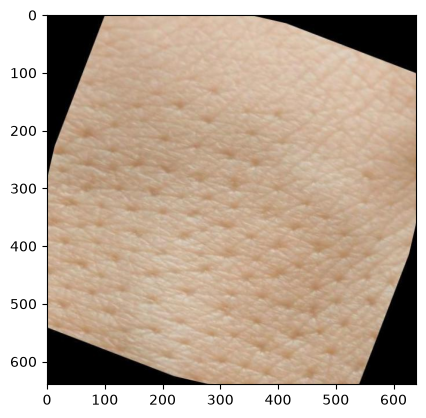

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("57_PNG.jpg", cv2.IMREAD_COLOR_RGB)

plt.imshow(image)

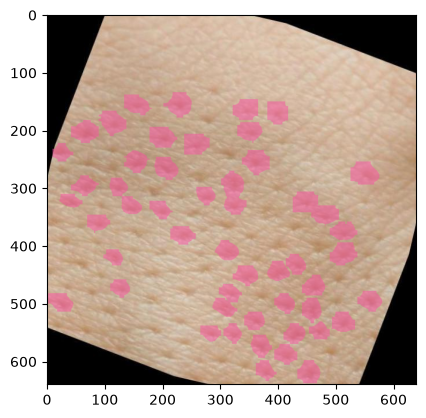

: 

In [ ]:
import supervision as sv

with CLIENT.use_configuration(custom_config):
    result = CLIENT.infer(inference_input=image, model_id=MODEL_ID)

detections = sv.Detections.from_inference(result)

annotator = sv.MaskAnnotator()

annotated = annotator.annotate(
    scene=image.copy(),
    detections=detections
)

plt.imshow(annotated)